# Week 4 - Task 8: Ensemble Learning

## Random Forest vs XGBoost

This notebook compares Random Forest and XGBoost with earlier machine learning models using the Titanic dataset. The models are evaluated based on their classification performance, and feature importance is analyzed to identify the most influential features.

In [1]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 1.9 MB/s eta 0:00:26
    --------------------------------------- 1.0/48.9 MB 1.8 MB/s eta 0:00:27
    --------------------------------------- 1.0/48.9 MB 1.8 MB/s eta 0:00:27
   - -------------------------------------- 1.6/48.9 MB 1.6 MB/s eta 0:00:31
   - -------------------------------------- 2.1/48.9 MB 1.6 MB/s eta 0:00:30
   - -------------------------------------- 2.4/48.9 MB 1.6 MB/s eta 0:00:30
   - -------------------------------------- 2.4/48.9 MB 1.6 MB/s eta 0:00:30
   - -------------------------------------- 2.4/48.9 MB 1.6 MB/s eta 0:00:30
   -- ------------------------------------- 3.1/48.9 MB 1.4 MB/s eta 0:00:32
   -- ---------------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Import Libraries

The required Python libraries are imported for data manipulation, visualization, preprocessing, model training, evaluation, and feature importance analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

## 2. Load the Dataset

The Titanic dataset used in the previous tasks is loaded from the Week 4 Task 7 folder so that the ensemble models can be compared using the same dataset.

In [3]:
df = pd.read_csv("../Task7/train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Data Preprocessing

The target variable is separated from the input features. Unnecessary columns such as PassengerId, Name, Ticket, and Cabin are removed. Numerical missing values are handled using the median, while categorical missing values are handled using the most frequent value. Categorical features are converted into numerical form using One-Hot Encoding.

In [4]:
# Separate features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Remove unnecessary columns
X = X.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

# Identify numerical and categorical columns
numerical_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]

# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 4. Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the models, while the testing set is used to evaluate their performance on unseen data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


## 5. Train Earlier Single Models

Logistic Regression and Decision Tree are used as baseline models. Their performance will later be compared with the ensemble models, Random Forest and XGBoost.

In [6]:
# Logistic Regression pipeline
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train Logistic Regression
logistic_model.fit(X_train, y_train)

# Predictions
logistic_pred = logistic_model.predict(X_test)

# Accuracy
logistic_accuracy = accuracy_score(y_test, logistic_pred)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.8044692737430168


## 6. Decision Tree Classifier

A Decision Tree Classifier is trained as another single-model baseline for comparison with the ensemble methods.

In [7]:
# Decision Tree pipeline
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

# Train Decision Tree
decision_tree_model.fit(X_train, y_train)

# Predictions
decision_tree_pred = decision_tree_model.predict(X_test)

# Accuracy
decision_tree_accuracy = accuracy_score(y_test, decision_tree_pred)

print("Decision Tree Accuracy:", decision_tree_accuracy)

Decision Tree Accuracy: 0.7597765363128491


## 7. Random Forest Classifier

Random Forest is an ensemble learning method that combines multiple decision trees. It uses random subsets of data and features to build diverse trees and combines their predictions to improve robustness and reduce overfitting.

In [8]:
# Random Forest pipeline
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train Random Forest
random_forest_model.fit(X_train, y_train)

# Predictions
random_forest_pred = random_forest_model.predict(X_test)

# Accuracy
random_forest_accuracy = accuracy_score(y_test, random_forest_pred)

print("Random Forest Accuracy:", random_forest_accuracy)

Random Forest Accuracy: 0.8044692737430168


## 8. XGBoost Classifier

XGBoost is a boosting-based ensemble learning algorithm that builds decision trees sequentially. Each new tree attempts to improve the errors made by the previous trees, allowing the model to achieve strong predictive performance.

In [9]:
# XGBoost pipeline
xgboost_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric="logloss"
    ))
])

# Train XGBoost
xgboost_model.fit(X_train, y_train)

# Predictions
xgboost_pred = xgboost_model.predict(X_test)

# Accuracy
xgboost_accuracy = accuracy_score(y_test, xgboost_pred)

print("XGBoost Accuracy:", xgboost_accuracy)

XGBoost Accuracy: 0.7988826815642458


## 9. Model Performance Comparison

The performance of the baseline and ensemble models is compared using accuracy on the test dataset.

In [10]:
# Create model comparison table

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Metric": [
        "Accuracy",
        "Accuracy",
        "Accuracy",
        "Accuracy"
    ],
    "Score": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        xgboost_accuracy
    ]
})

# Convert scores to percentages
results["Score (%)"] = results["Score"] * 100

results

,Model,Metric,Score,Score (%)
0,Logistic Regression,Accuracy,0.804469,80.446927
1,Decision Tree,Accuracy,0.759777,75.977654
2,Random Forest,Accuracy,0.804469,80.446927
3,XGBoost,Accuracy,0.798883,79.888268


## 10. Model Accuracy Comparison

The following bar chart provides a visual comparison of the accuracy achieved by all four models.

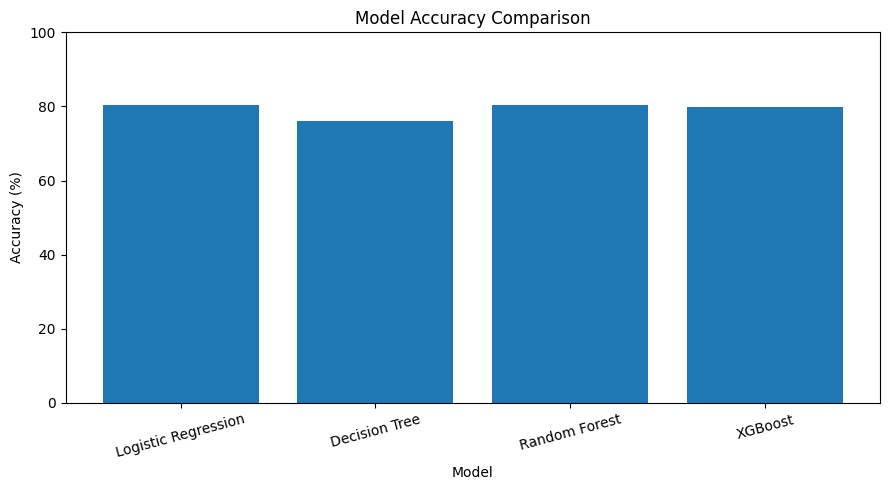

In [11]:
plt.figure(figsize=(9, 5))

plt.bar(results["Model"], results["Score (%)"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

## 11. Random Forest Feature Importance

Feature importance shows which input features contribute most to the Random Forest model's predictions. The importance values are extracted from the trained Random Forest model and visualized for comparison.

In [12]:
# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Get Random Forest feature importances
rf_importances = random_forest_model.named_steps["classifier"].feature_importances_

# Create feature importance DataFrame
rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

# Display top features
rf_importance_df.head(10)

,Feature,Importance
3,num__Fare,0.250398
0,num__Age,0.246040
8,cat__Sex_male,0.157727
7,cat__Sex_female,0.124618
1,num__SibSp,0.047323
6,cat__Pclass_3,0.046408
2,num__Parch,0.038750
4,cat__Pclass_1,0.034596
5,cat__Pclass_2,0.017260
11,cat__Embarked_S,0.017207


### Random Forest Feature Importance Plot

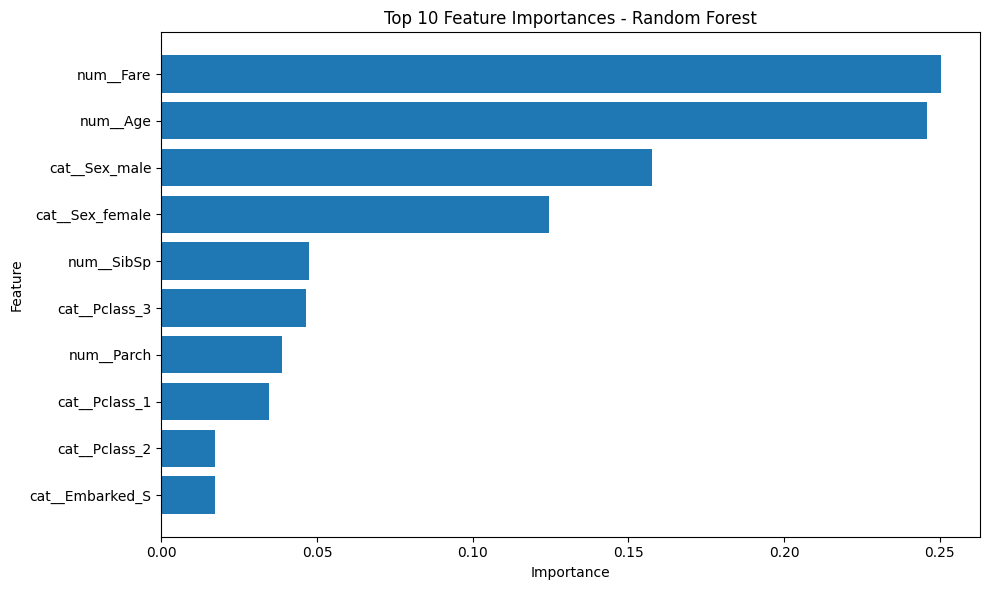

In [13]:
plt.figure(figsize=(10, 6))

top_rf = rf_importance_df.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.barh(top_rf["Feature"], top_rf["Importance"])

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

# Save the figure
plt.savefig("random_forest_importance.png", dpi=300, bbox_inches="tight")

plt.show()

## 12. XGBoost Feature Importance

Feature importance is extracted from the trained XGBoost model to identify the features that contribute most to its predictions. These results are visualized and compared with the Random Forest feature importance.

In [14]:
# Get XGBoost feature importances
xgb_importances = xgboost_model.named_steps["classifier"].feature_importances_

# Create feature importance DataFrame
xgb_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_importances
}).sort_values(by="Importance", ascending=False)

# Display top features
xgb_importance_df.head(10)

,Feature,Importance
7,cat__Sex_female,0.465654
6,cat__Pclass_3,0.210080
4,cat__Pclass_1,0.093016
11,cat__Embarked_S,0.054731
1,num__SibSp,0.042451
0,num__Age,0.040160
3,num__Fare,0.039446
5,cat__Pclass_2,0.022655
9,cat__Embarked_C,0.019760
2,num__Parch,0.010568


### XGBoost Feature Importance Plot

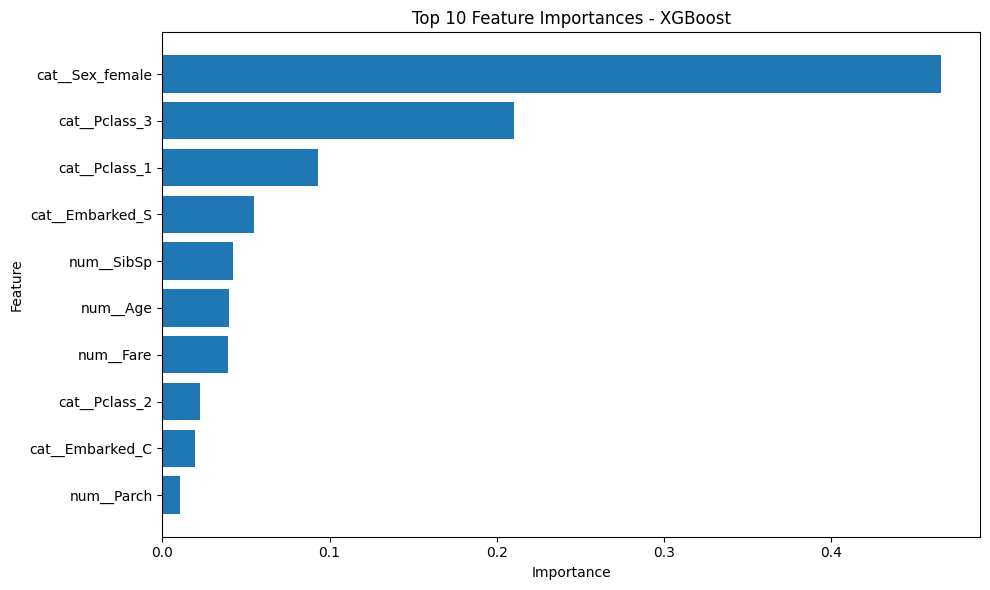

In [15]:
plt.figure(figsize=(10, 6))

top_xgb = xgb_importance_df.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.barh(top_xgb["Feature"], top_xgb["Importance"])

plt.title("Top 10 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

# Save the figure
plt.savefig("xgboost_importance.png", dpi=300, bbox_inches="tight")

plt.show()

## 13. Random Forest vs XGBoost Feature Importance

The feature importance results from Random Forest and XGBoost are compared to identify which features are considered most influential by each ensemble model.

In [16]:
# Compare top 10 features from both models

feature_comparison = pd.DataFrame({
    "Feature": feature_names,
    "Random Forest Importance": rf_importances,
    "XGBoost Importance": xgb_importances
})

feature_comparison = feature_comparison.sort_values(
    by="Random Forest Importance",
    ascending=False
)

feature_comparison.head(10)

,Feature,Random Forest Importance,XGBoost Importance
3,num__Fare,0.250398,0.039446
0,num__Age,0.246040,0.040160
8,cat__Sex_male,0.157727,0.000000
7,cat__Sex_female,0.124618,0.465654
1,num__SibSp,0.047323,0.042451
6,cat__Pclass_3,0.046408,0.210080
2,num__Parch,0.038750,0.010568
4,cat__Pclass_1,0.034596,0.093016
5,cat__Pclass_2,0.017260,0.022655
11,cat__Embarked_S,0.017207,0.054731


##  Random Forest vs XGBoost

Random Forest combines multiple decision trees that are trained independently using random subsets of the data and features. XGBoost builds trees sequentially, where each new tree focuses on improving the errors made by the previous trees. Random Forest uses a bagging approach to reduce variance and overfitting, while XGBoost uses boosting to improve prediction performance. In this experiment, Random Forest achieved 80.45% accuracy, while XGBoost achieved 79.89% accuracy.

##  Conclusion

Among the four tested models, Logistic Regression and Random Forest achieved the highest accuracy of 80.45%. XGBoost achieved 79.89%, while the Decision Tree achieved 75.98%. The results show that ensemble methods can provide competitive performance compared with traditional single models, although the best model can vary depending on the dataset and model configuration.